# Welltory COVID-19 Exploratory Data Analysis

Author: Justin Winkler

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

# Load the participants dataset
data_dir = Path("welltory-data").resolve()
participants = pd.read_csv(data_dir / "participants.csv")
heart_rate = pd.read_csv(data_dir / "heart_rate.csv")
hrv_measurements = pd.read_csv(data_dir / "hrv_measurements.csv")

# Convert date columns to datetime objects for numerical manipulation
participants["symptoms_onset"] = pd.to_datetime(participants.symptoms_onset)
heart_rate["datetime"] = pd.to_datetime(heart_rate.datetime)
hrv_measurements["measurement_datetime"] = pd.to_datetime(hrv_measurements.measurement_datetime)

# Use ordinal encoding for age range to preserve natural ordering
participants["age_range"] = participants["age_range"].map({
    "18-24": 0, 
    "25-34": 1, 
    "35-44": 2,
    "45-54": 3,
    "55-64": 4,
    "65-74": 5,
})

# Use ordinal encoding for time of day to preserve natural ordering
hrv_measurements["time_of_day"] = hrv_measurements["time_of_day"].map({
    "morning": 0,
    "day": 1,
    "evening": 2,
    "night": 3,
})

datasets_by_name = {
    "Participants": participants,
    "Heart Rate": heart_rate,
    "Heart Rate Variability": hrv_measurements,
}

## Questions we are asking:
* What are the dimensions of the dataset (number of rows and columns)?
* What are the data types of the variables (numerical, categorical, text, etc.)?
* Are there any missing values, and if so, how are they represented?


In [ ]:
# Data Structure
print("Data Structure")
print("~~~~~~~~~~~~~~")
print()

for df_name, df in datasets_by_name.items():
    print(f"{df_name}")
    print(f"{len(df_name) * '-'}")
    print(f"Dimensions: {df.shape}")
    print(f"Data Types:\n{df.dtypes}")
    print(f"Missing Values:\n{df.isnull().sum()}")
    print()

Data Structure
~~~~~~~~~~~~~~

Participants
------------
Dimensions: (185, 8)
Data Types:
user_code                 object
gender                    object
age_range                  int64
city                      object
country                   object
height                   float64
weight                   float64
symptoms_onset    datetime64[ns]
dtype: object
Missing Values:
user_code          0
gender             0
age_range          0
city              12
country            6
height             2
weight             0
symptoms_onset    38
dtype: int64

Heart Rate
----------
Dimensions: (523783, 4)
Data Types:
user_code             object
datetime      datetime64[ns]
heart_rate             int64
is_resting             int64
dtype: object
Missing Values:
user_code     0
datetime      0
heart_rate    0
is_resting    0
dtype: int64

Heart Rate Variability
----------------------
Dimensions: (3245, 22)
Data Types:
user_code                       object
rr_code                         

## Interpretation

#### Participants

The participants dataset contains information about 185 COVID-positive participants, each having 6 categorical features describing biographical information, the date that the onset of COVID symptoms occured on, and a unique participant ID as well as 2 numerical features describing participant height and weight. 

Categorical biographical information collected about participants includes age (range), country, and city. The symptom onset date includes only the dat in mm/dd/yyyy format, making the feature categorical even though dates can be considered numerical in some cases. The unique participant ID allows for participant matching across datasets.

The dataset contains some missing values for the biographical columns. These missing values are represented by empty strings in the CSV files (NaN after loading into DataFrames). The "symptoms_onset" field also contains some missing values. At first, I thought this might indicate that the corresponding participant did not contract COVID-19, which would have been valuable information to capture in the form of a binary missing flag. After reading the following line in the README for the Welltory dataset, however, I believe the researchers are explaining that all participants in the study were at one point COVID-positive:

```md
As part of the research, our users with positive COVID-19 status tracked their symptoms, heart rate variability, and data with the Welltory app.
```

To me, this suggests that there was an error in capturing the information during the collection process. If possible, this would have been a good opportunity to address that issue, but for the purposes of this assignment, I will drop the rows missing a value for this field.

#### Heart Rate

The heart rate dataset contains 523783 heart rate observations from the participants described in the above dataset. Each observation is characterized by four variables: an ID indicating the participant the reading was taken from and a indication of whether the observation was taken at rest (both categorical variables) as well as the heart rate recording (in bpm) and a datetime object representing the date and time the observation was made (both numerical variables).

The heart rate dataset is complete and will require no imputation.

#### Heart Rate Variability

The heart rate variability data includes an abundance of data related to statistics that measure heart rate variability. There are 3245 rows in the dataset corresponding to 3245 observations of participants' heart rate variability recorded Welltory's wearable devices. Each observation contains a recording code and a user code. Respectively, these categorical variables help uniquely identify the recording and match the recording to other user data. Each observation also contains a numerical datetime object and a categorical "time_of_day" feature (presumably not redundant because datetime values may be timezone-independent) to reflect the time at which the recording was taken. The following are numerical features that provide useful insight about heart rate variability relevant to COVID-19 diagnoses (descriptions are reproduced exactly from the dataset's original repository README):

 | **Column** | **Description** | **Units** |
 |--------------- |----------------------------------------------------------------------------------------- |------------------ |
 | bpm | Heart rate during measurement | beats per minute |
 | meanrr | Mean RR — average time between each heartbeat. | milliseconds |
 | mxdmn | MxDMn — the difference between highest and lowest cardio interval values. | seconds |
 | sdnn | SDNN — standard deviation of normal heartbeat intervals. | milliseconds |
 | rmssd | rMSSD — root mean square of successive differences for consecutive intervals. | milliseconds |
 | pnn50 | PNN50 — percent of RR-intervals that fall outside a 50 ms range of the average. | % |
 | mode | Moda — the most common cardio interval length in a measurement. | milliseconds |
 | amo | AMo50 — mode amplitude. | %/50milliseconds |
 | lf | LF — the power of low frequency waves. | milliseconds² |
 | hf | HF — the power of high frequency waves. | milliseconds² |
 | vlf | VLF — power of very low frequency waves. | milliseconds² |
 | lfhf | LF/HF — ratio of low to high frequency waves. | |
 | total\_power | Total Power — the total power of HF, LF, and VLF waves generated by the heart. | milliseconds² |
 | rr\_data | Intervals in milliseconds between consecutive heart beats as a comma-separated string | |

Finally, the dataset contains four more categorical features, "how_sleep," "how_feel," "how_mood," and "tags" to further qualify subjective patient conditions and circumstances at the time of measurement. These features, however, are sparsely recorded, poorly documented, or both, so I plan on dropping them later on.

Aside from these few features, the dataset is complete and will require no imputation.

## Action

Drop the "how_sleep," "how_feel," "how_mood," and "tags" features because they are sparsely recorded and poorly documented.

In [ ]:
hrv_measurements = hrv_measurements.drop(columns=["how_sleep", "how_feel", "how_mood", "tags" ])
datasets_by_name["Heart Rate Variability"] = hrv_measurements

## Questions we are asking:
* What are the central tendency measures (mean, median, mode) for numerical variables?
* What are the measures of dispersion (range, variance, standard deviation) for numerical variables?
* What is the distribution of the variables (normal, skewed, etc.)?


In [ ]:
# Descriptive Statistics
print("\nDescriptive Statistics")
print("~~~~~~~~~~~~~~~~~~~~~~")
print()

for df_name, df in datasets_by_name.items():
    print(f"{df_name}")
    print(f"{len(df_name) * '-'}")

    numeric_columns = df.select_dtypes(include=[np.number]).columns
    print("Central Tendency Measures:")
    print(df[numeric_columns].describe().loc[["mean", '50%']])
    print("\nDispersion Measures:")
    print(df[numeric_columns].describe().loc[['std', 'min', 'max']])

    # Check for distribution normality (skewness and kurtosis)
    print("\nDistribution Measures:")
    print("Skew:")
    print(df[numeric_columns].skew())
    print("Kurtosis:")
    print(df[numeric_columns].kurt())


Descriptive Statistics
~~~~~~~~~~~~~~~~~~~~~~

Participants
------------
Central Tendency Measures:
      age_range      height     weight
mean   2.064865  169.976393  77.927757
50%    2.000000  168.000000  74.344000

Dispersion Measures:
     age_range      height      weight
std   1.186934   12.400103   19.552541
min   0.000000  132.080000   43.500000
max   5.000000  250.000000  154.221000

Distribution Measures:
Skew:
age_range    0.287516
height       2.910275
weight       0.865345
dtype: float64
Kurtosis:
age_range    -0.122206
height       17.552808
weight        0.891368
dtype: float64
Heart Rate
----------
Central Tendency Measures:
      heart_rate  is_resting
mean   90.856626    0.005546
50%    87.000000    0.000000

Dispersion Measures:
     heart_rate  is_resting
std   25.054152    0.074266
min   10.000000    0.000000
max  232.000000    1.000000

Distribution Measures:
Skew:
heart_rate     0.627198
is_resting    13.315801
dtype: float64
Kurtosis:
heart_rate      0.032379
i

## Interpretation

#### Descriptive Statistics

The mean and median provide insights into the central location of the data. For example, the mean and median values for the heart_rate variable tell us that the average heart rate was approximiately 90 bpm while 50% of heart rate observations fell below 87 bpm and the other 50% of observations were above 87 bpm.

Comparing these values for each variable also gives us a clue about the skewness of the variable's distribution.

##### Participants

| Feature | Mean/Median comparison | Skewness |
|--------- |------------------------ |---------- |
| age_range | mean ~ median | symmetric |
| height | mean ~ median | symmetric |
| weight | mean > median | right-skew |

##### Heart Rate

| Feature | Mean/Median comparison | Skewness |
|--------- |------------------------ |---------- |
| heart_rate | mean > median | right-skew |

##### Heart Rate Variability

| Feature | Mean/Median comparison | Skewness |
|--------- |------------------------ |---------- |
| bpm | mean > median | slight right-skew |
| meanrr | mean ~ median | relatively symmetric |
| mxdmn | mean > median | right-skew |
| sdnn | mean > median | right-skew |
| rmssd | mean > median | right-skew |
| pnn50 | mean > median | right-skew |
| mode | mean ~ median | symmetric |
| amo | mean ~ median | symmetric |
| lf | mean >> median | heavy right-skew |
| hf | mean >> median | heavy right-skew |
| vlf | mean >> median | heavy right-skew |
| lfhf | mean >> median | heavy right-skew |
| total_power | mean >> median | heavy right-skew |

#### Dispersion Measures

Dispersion measures (such as standard deviation, min, max, Q1, Q3, and IQR) describe the spread of distributions.

For example, the standard deviation of the heart rate variable indicates that individual heart rate observations deviated from the mean by an average value of about 25 bpm. 

#### Distribution Measures

Distributions provide insight about the shape (skewness and kurtosis) of a distribution.

Skewness values close to 0 indicate a symmetric distribution, while positive or negative values indicate right or left skew, respectively. Kurtosis indicates the "tailedness" of the distribution; values close to 0 suggest a normal distribution, while higher values suggest heavier tails.

Using the computed values for these statistics to check my asummptions about the skewness of each variable's distribution based on measures of central location, I see that I was mostly correct, if not a bit sensitive to calling distributions skewed.

## Questions we are asking:
* Are there any duplicated rows or inconsistent values?
* Are there any outliers or extreme values that need attention?
* Do the values make sense based on the context and domain knowledge?


In [ ]:
# Data Quality
print("\nData Quality")
print("~~~~~~~~~~~~")
print()

print("Participants")
print("------------")
print(f"Duplicated Rows: {participants.duplicated(subset=['user_code']).sum()}")
print("Checking for Inconsistent Values:")
print(participants.apply(lambda x: x.value_counts().index[0]).to_frame('most_frequent_value'))
print("Checking for potential outliers:")
iqr_outliers = participants.select_dtypes('number').apply(lambda x: ~x.between(x.quantile(.25) - 1.5*(x.quantile(.75) - x.quantile(.25)), x.quantile(.75) + 1.5*(x.quantile(.75) - x.quantile(.25))))
print(iqr_outliers.sum())
print()

print("Heart Rate")
print("----------")
print(f"Duplicated Rows: {heart_rate.duplicated(subset=['user_code', 'datetime']).sum()}")
print("Checking for Inconsistent Values:")
print(heart_rate.apply(lambda x: x.value_counts().index[0]).to_frame('most_frequent_value'))
print("Checking for potential outliers:")
iqr_outliers = heart_rate.select_dtypes('number').apply(lambda x: ~x.between(x.quantile(.25) - 1.5*(x.quantile(.75) - x.quantile(.25)), x.quantile(.75) + 1.5*(x.quantile(.75) - x.quantile(.25))))
print(iqr_outliers.sum())
print()

print("Heart Rate Variability")
print("----------------------")
print(f"Duplicated Rows: {hrv_measurements.duplicated().sum()}")
print("Checking for Inconsistent Values:")
print(hrv_measurements.apply(lambda x: x.value_counts().index[0]).to_frame('most_frequent_value'))
print("Checking for potential outliers:")
iqr_outliers = hrv_measurements.select_dtypes('number').apply(lambda x: ~x.between(x.quantile(.25) - 1.5*(x.quantile(.75) - x.quantile(.25)), x.quantile(.75) + 1.5*(x.quantile(.75) - x.quantile(.25))))
print(iqr_outliers.sum())
print()



Data Quality
~~~~~~~~~~~~

Participants
------------
Duplicated Rows: 0
Checking for Inconsistent Values:
                most_frequent_value
user_code                007b8190cf
gender                            f
age_range                         2
city                         Moscow
country                      Russia
height                        168.0
weight                         60.0
symptoms_onset  2020-05-06 00:00:00
Checking for potential outliers:
age_range    0
height       8
weight       3
dtype: int64

Heart Rate
----------
Duplicated Rows: 7330
Checking for Inconsistent Values:
            most_frequent_value
user_code            35c7355282
datetime    2020-05-10 13:00:00
heart_rate                   78
is_resting                    0
Checking for potential outliers:
heart_rate    3802
is_resting    2905
dtype: int64

Heart Rate Variability
----------------------
Duplicated Rows: 0
Checking for Inconsistent Values:
                                                    mos

## Interpretation

Duplicated Rows: There are 7330 duplicated recordings in the heart rate dataset. There are no duplicates in the other datasets.

Inconsistent Values: I've used two methods of determining inconsistent values above.

The first nethod, most frequent value calculation, determines whether any values are being recorded with suspicious frequency. A value that is mistakenly repeated may indicate that there was a measurement error (e.g. a sensor that continues to record the same value or value range), an experimental error (e.g. a survey question that was not clear; may be the case for the symptom_onset variable discussed above), or a data processing error on my part.

The second method I've used for determining inconsistent values is the IQR method for detecting outliers. This flags values as potential outliers if they fall outside the range [Q1-(1.5*(Q3-Q1)),Q3+(1.5*(Q3-Q1))]. All three of the datasets above contain potential outliers. The next step would be to consult subject matter experts and determine whether the most extreme values are outliers or actually just interesting observations that need to be kept for training purposes.

Given my own understanding of the dataset, I feel confident determining that symptom onset dates from prior to the COVID-19 pandemic have been recorded in error. There are also two symptom onset observations from after the last of the heart rate data observations. Accordingly, I will drop those values.

## Action

Drop duplicate heart rate recordings.

Drop participants with symptom onset dates prior to November 11, 2019 and after June 16, 2020 (the day of the last heart rate observation).

In [ ]:
# Drop duplicte heart rate recordings
heart_rate = heart_rate.drop_duplicates(subset=["user_code", "datetime"])
datasets_by_name["Heart Rate"] = heart_rate

# Drop participants with symptom onsets prior to Nov. 17 2019, the date of the 
# first recorded COVID-19 case.
# 
# It looks possible that participants recorded their date of birth instead of 
# symptom onset date here. This would be a good assumption to check with the 
# scientists who are familiar with the way that this data was recorded.
#
# Note: This also drops the NaT values for symptom onset discussed earlier, 
# resulting in a total of 51/185 (28%) of participants dropped.
participants = participants.loc[(participants.symptoms_onset > '2019-11-17')]
participants = participants.loc[(participants.symptoms_onset < '2020-06-19')]
datasets_by_name["Participants"] = participants

## Questions we are asking:

* Is there any correlation between pairs of numerical variables?
* Are there any noticeable patterns or trends in the data?
* How are categorical variables related to numerical variables?



Variable Relationships
~~~~~~~~~~~~~~~~~~~~~~

Participants Correlation Matrix:
           age_range    height    weight
age_range   1.000000 -0.026221  0.252513
height     -0.026221  1.000000  0.280625
weight      0.252513  0.280625  1.000000


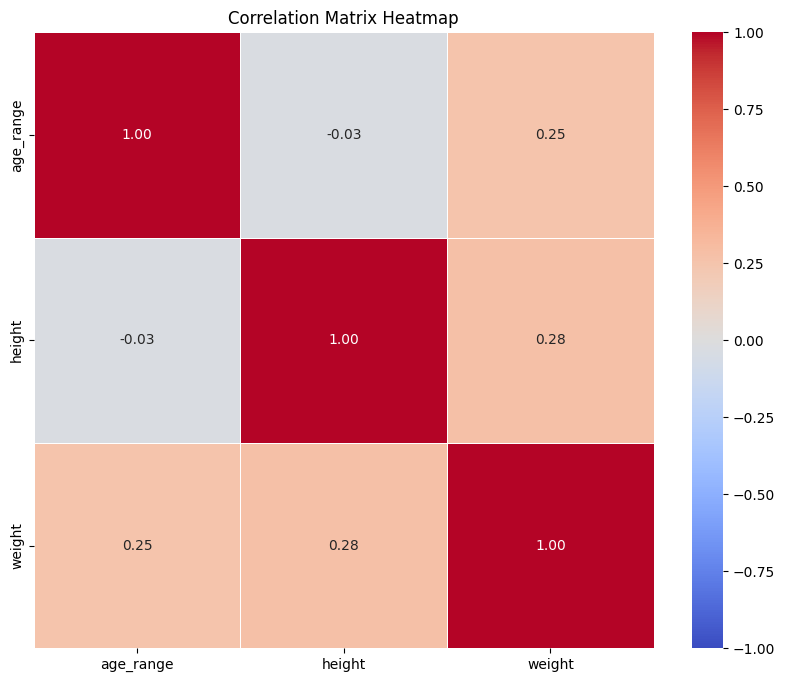

Heart Rate Correlation Matrix:
            heart_rate  is_resting
heart_rate    1.000000   -0.079783
is_resting   -0.079783    1.000000


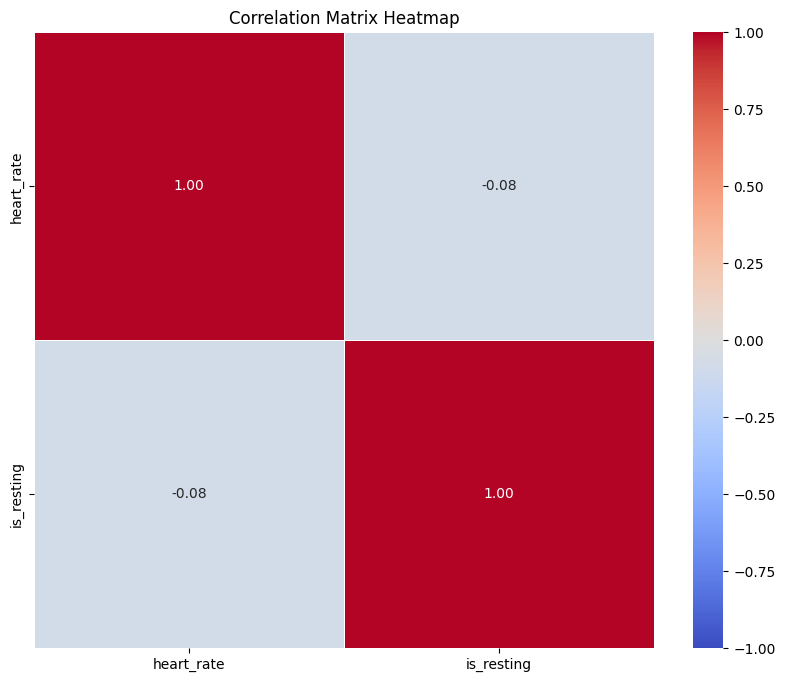

Heart Rate Variability Correlation Matrix:
             time_of_day       bpm    meanrr     mxdmn      sdnn     rmssd  \
time_of_day     1.000000  0.215956 -0.231349 -0.133008 -0.134731 -0.049980   
bpm             0.215956  1.000000 -0.977724 -0.343935 -0.341514 -0.214339   
meanrr         -0.231349 -0.977724  1.000000  0.348015  0.348052  0.231696   
mxdmn          -0.133008 -0.343935  0.348015  1.000000  0.954639  0.846259   
sdnn           -0.134731 -0.341514  0.348052  0.954639  1.000000  0.909046   
rmssd          -0.049980 -0.214339  0.231696  0.846259  0.909046  1.000000   
pnn50          -0.122852 -0.408006  0.445640  0.777242  0.810236  0.843065   
mode           -0.231208 -0.956984  0.979400  0.262628  0.258114  0.128843   
amo             0.191960  0.547373 -0.533668 -0.750213 -0.759049 -0.595028   
lf             -0.079524 -0.171505  0.176511  0.717783  0.743380  0.629966   
hf             -0.032644 -0.105204  0.128630  0.740832  0.773958  0.857374   
vlf            -0.117

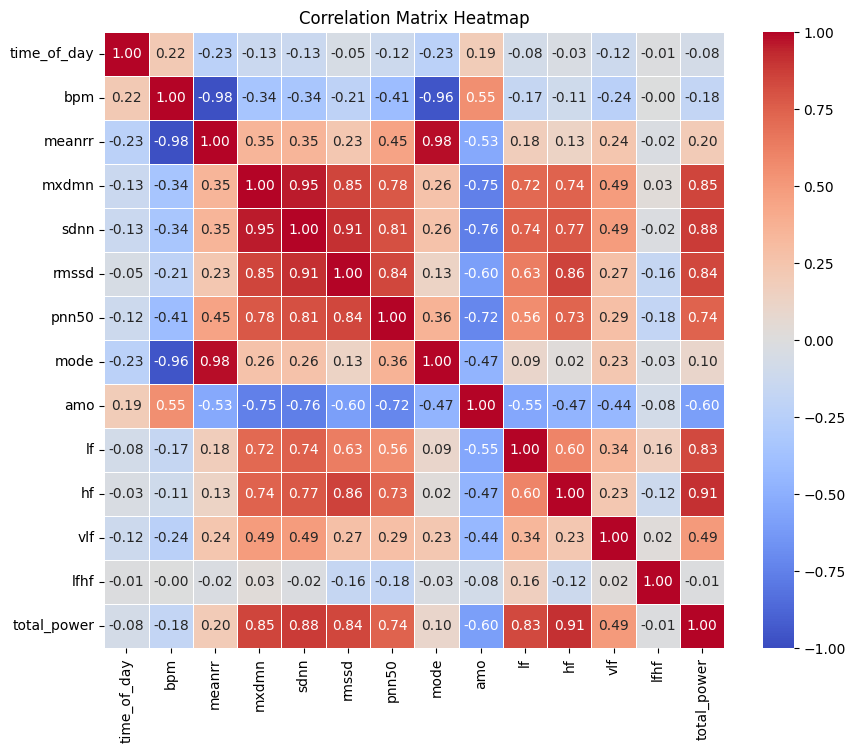

In [ ]:
# Variable Relationships
print("\nVariable Relationships")
print("~~~~~~~~~~~~~~~~~~~~~~")
print()

for df_name, df in datasets_by_name.items():
    print(f"{df_name} Correlation Matrix:")
    numeric_columns = df.select_dtypes(include=[np.number]).columns
    correlation_matrix = df[numeric_columns].corr()
    print(correlation_matrix)

    # Visualize the Correlation Matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5, vmin=-1, vmax=1)
    plt.title('Correlation Matrix Heatmap')
    plt.show()

## Interpretation

Positive correlation values (close to 1) indicate a strong direct relationship, while negative values (close to -1) indicate an inverse relationship.

The heat maps above visually demonstrate the correlation between each pair of variables for the three datasets. The first two plots show that there is no strong correlation (positive or negative) between pairs of variables within the participants and heart rate datasets.

The heart rate variability heat map tells a different story; while the majority of feature pairs exhibit little to no correlative relationship, each pair for the set of variables mxdmn (the difference between highest and lowest cardio interval values), sdnn (standard deviation of normal heartbeat intervals), rmssd (root mean square of successive differences for consecutive intervals), and pnn50 (percent of RR-intervals that fall outside a 50 ms range of the average) demonstrates a strong positive correlation. This is not surprising since these are all measures of the variations observed in participant heart rates. When one increases, the others are bound to as well.

## Questions we are asking:

* How can the variables be visualized effectively (histograms, scatterplots, box plots, etc.)?
* Do the visualizations reveal any interesting patterns or insights?
* Are there any subgroups or clusters that can be identified visually?



Data Visualization
~~~~~~~~~~~~~~~~~~~~~~

Participants
------------


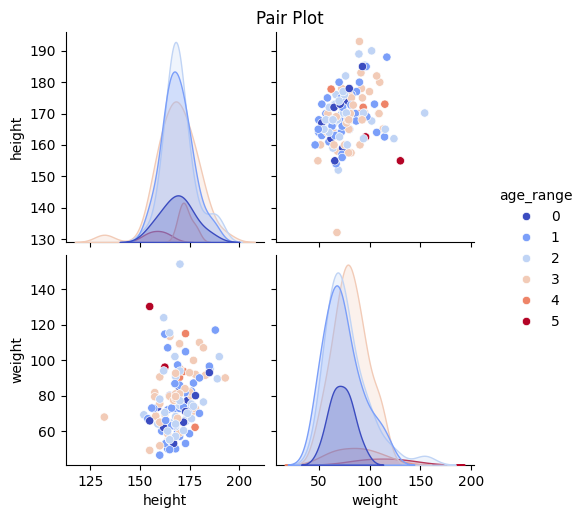

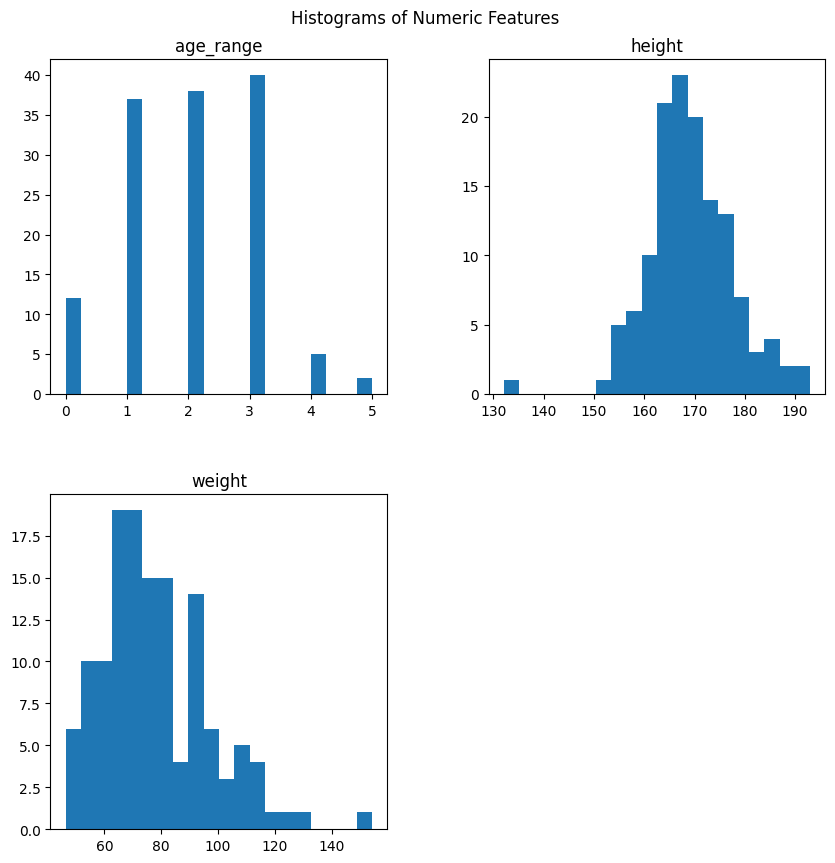

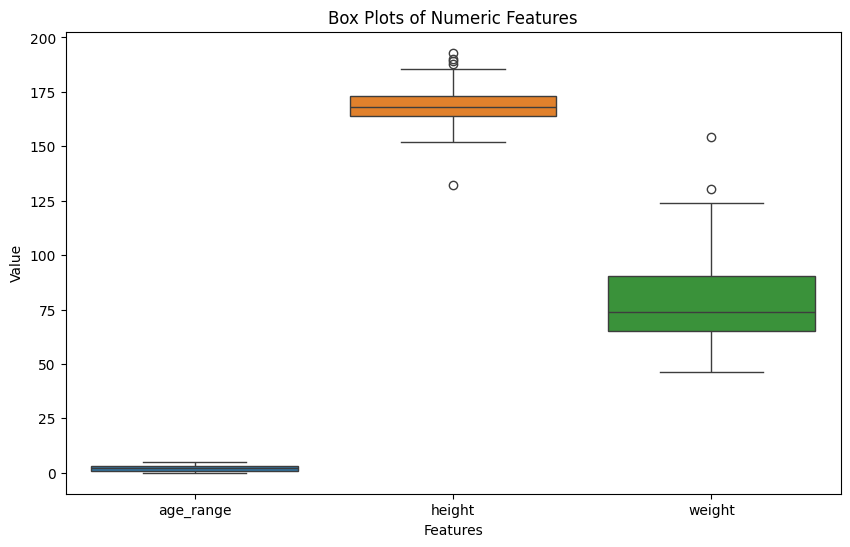

In [ ]:
# Data Visualization
print("\nData Visualization")
print("~~~~~~~~~~~~~~~~~~~~~~")
print()

print("Participants")
print("------------")

sns.pairplot(participants, hue='age_range', palette="coolwarm")
plt.suptitle('Pair Plot', y=1.02)
plt.show()

# Visualize distributions
numeric_columns = participants.select_dtypes(include=[np.number]).columns
participants[numeric_columns].hist(bins=20, figsize=(10,10), grid=False)
plt.suptitle('Histograms of Numeric Features', y=0.93)
plt.show()

# Box plots to identify outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=participants[numeric_columns])
plt.title('Box Plots of Numeric Features')
plt.xlabel('Features')
plt.ylabel('Value')
plt.show()

## Interpretation

#### Pair Plot:

Pair plots plot scatterplots of pairs of features of each dataset against each other. The plots on the diagonal at the intersection of the row and column containing the same variable plot histograms of the variable. It is also possible to configure these plots to color groups of observations, as I did here, to distinguish between the patterns exhibited by those groups for each variable.

The histograms for the participants dataset show normal and right-skewed distributions for the weight variable across age ranges and a variety of normal, right-skewed, and left-skewed distributions for the height variable.

The pair plots do not demonstrate any clustering patterns for any age group for either the height or the weight variables.

#### Histograms:

The histograms I've plotted display the distribution of each numerical feature of the participants dataset. The age range distribution shows that most observations come from participants in the 25-34, 35-44 and 45-54 ranges. The distributions for height and weight look mostly normal to slightly right-skewed. The histogram for height shows some extreme observation on the low end of the scale.

#### Box Plots:

While box plots also capture some of the same information about spread that the histograms above do, they also more clearly spot potential outlies. These are marked by the dots that fall on the outside of the whiskers of plots. For example, the plots above identify some potential outliers to the right of the weight distribution and some potential outliers on either side of the height distribution. If possible, it would be good to investigate whether these observations were recorded in error somehow or are otherwise important anomalies.

## Questions we are asking:

* Are there any new features that can be derived from the existing ones?
* Is there a need to transform or scale any variables?
* Are there any variables that can be combined or decomposed?



Feature Engineering
-------------------


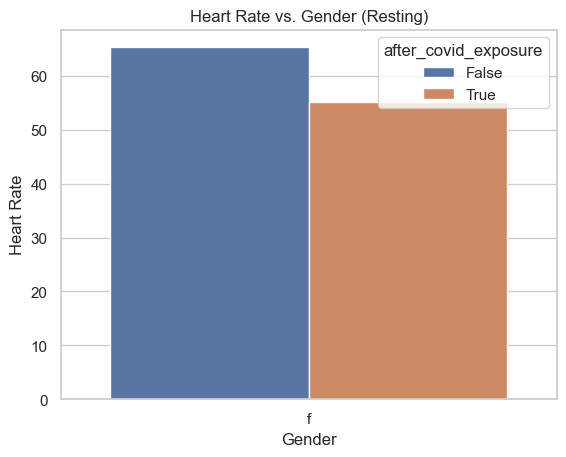

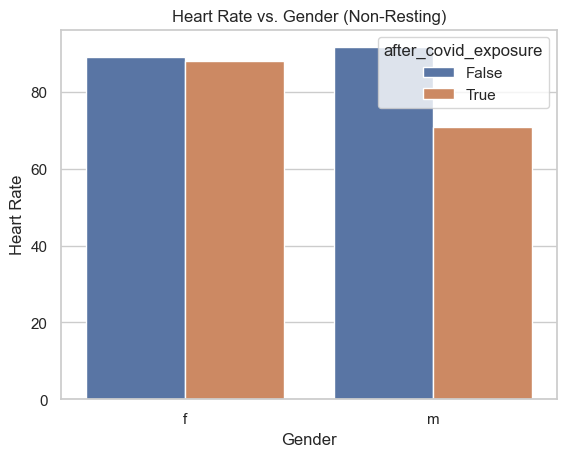

In [ ]:
# Feature Engineering
print("\nFeature Engineering")
print("-------------------")

# Combine participant biographical information with heart rate and heart rate variability observations.
participants_hr = pd.merge(participants, heart_rate, on="user_code", how="inner")
participants_hrv = pd.merge(participants, hrv_measurements, on="user_code", how="inner")

# Convert heart rate recording datetime column to a "days since symptom onset" measurement
participants_hr["days_since_symptom_onset"] = (participants_hr["datetime"] - participants_hr["symptoms_onset"]).dt.days
participants_hr.drop(columns=["symptoms_onset", "datetime"], inplace=True)

participants_hrv["days_since_symptom_onset"] = (participants_hrv["measurement_datetime"] - participants_hrv["symptoms_onset"]).dt.days
participants_hrv.drop(columns=["symptoms_onset", "measurement_datetime"], inplace=True)

# Drop observations from after two week after symptom onset, when effects of COVID may be wearing off
participants_hr = participants_hr[participants_hr["days_since_symptom_onset"] < 14]
participants_hrv = participants_hrv[participants_hrv["days_since_symptom_onset"] < 14]

# Assume COVID exposure takes place ~5 days before symptom onset and create a feature denoting whether
# an observation was recorded before or after COVID exposure
participants_hr["after_covid_exposure"] = participants_hr.days_since_symptom_onset.between(-5, 14)
participants_hrv["after_covid_exposure"] = participants_hrv.days_since_symptom_onset.between(-5, 14)

# Split the dataframe into resting and non-resting observations
participants_resting_hr = participants_hr[participants_hr["is_resting"] == 1].groupby(['gender', 'after_covid_exposure'], as_index=False).agg(
    average_heart_rate=("heart_rate", "mean"),
)
participants_non_resting_hr = participants_hr[participants_hr["is_resting"] == 0].groupby(['gender', 'after_covid_exposure'], as_index=False).agg(
    average_heart_rate=("heart_rate", "mean"),
)

# Visualize new features
sns.set_theme(style="whitegrid")

ax = sns.barplot(x="gender",
        y="average_heart_rate",
        hue="after_covid_exposure",
        data=participants_resting_hr)
ax.set_title("Heart Rate vs. Gender (Resting)")
ax.set_xlabel("Gender")
ax.set_ylabel("Heart Rate")
plt.show()

ax = sns.barplot(x="gender",
        y="average_heart_rate",
        hue="after_covid_exposure",
        data=participants_non_resting_hr)
ax.set_title("Heart Rate vs. Gender (Non-Resting)")
ax.set_xlabel("Gender")
ax.set_ylabel("Heart Rate")
plt.show()

## Interpretation

#### New Features (days since symptom onset, measurement recorded before COVID exposure):
The existing datetime measurements on individual heart rate and heart rate variability recordings were not very informative on their own, but finding the difference between these datetimes and the datetimes describing symptom onset might be more relevant for comparing the effects of COVID on heart rate and heart rate variability statistics.

The bar charts above show that, for female participants, both resting and non-resting heart rates rose after the estimated date of COVID exposure. The data also shows that no resting heart rate observations for male participants remain after preprocessing. No conclusion can be made about the effect of COVID-19 on resting heart rate for males, the opposite that was said for females can be said for male non-resting heart rate: it *decreases* after exposure to COVID-19.

# Interpretation for Machine Learning

#### Profiling
Dimensions and data types were examined to understand the size and structure of the data. I read through the Welltory project README and dtypes.md files to ensure I understood the context of the data. Descriptive statistics were computed to help get an idea of the general shape, spread, and center of the dataset's variable distributions.

#### Completeness:
Careful handling of missing values is required to ensure that bias is not introduced as a result of a naive imputation strategy. I removed sparsely recorded, poorly documented variables from the heart rate variability dataset to avoid drawing conclusions from incomplete data.

#### Accuracy
I used my own knowledge of the domain to remove outliers in the symptom onset column of the participants dataset. Also, although I did not make the decision to remove observations in the height and weight distributions, I did flag some as potential observations using the IQR method. In a real-world application, I would have consulted with the scientists collecting the research to get more information as to whether those observations are valid.

#### Consistency
I converted all date/time fields to datetime objects to make it easier to perform computations on these observations. Furthermmore, I verified that other variables that can be measured in the same unit already were.

#### Integrity
Data integrity was verified by checking for duplicated rows, which, in turn, verified unique IDs. The merging of the participants and heart rate and heart rate variability datasets also ensured referential integrity between datasets because the merge was performed on these ID fields.

#### Lineage and Provenance
As previously mentioned, I read the dataset's documentation, understanding the source of the data to the extent possible. Furthermore, I did some light research on the topic of COVID-19's effect on heart rate and heart rate variability to get familiar with some of the measures recorded in the dataset.